<a href="https://colab.research.google.com/github/promckkon/MK2DimCNN/blob/main/HSPSO%20with%200dB%20NOISE%20in%20TR%20Data%20260504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# =========================================================
# Cell 1: 環境配置與套件載入 (Environment & Setup)
# =========================================================
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore') # 隱藏 Pandas FutureWarning

# 自動檢查並修復 CatBoost 與 NumPy 版本衝突
try:
    import catboost
    import numpy as np
    if catboost.__version__ != '1.2.7' or np.__version__ >= '2.0.0':
        raise ImportError
except:
    print("正在安裝穩定版環境 (NumPy 1.26.4 & CatBoost 1.2.7)...")
    get_ipython().system('pip install -q "numpy==1.26.4" "catboost==1.2.7" "scipy" "scikit-learn" "seaborn" "matplotlib"')
    print("--- 安裝完成！請點擊上方選單「執行階段」->「重新啟動執行階段」，然後再次執行此單元格 ---")


import scipy.io
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from datetime import datetime
import random

print("所有套件載入完成，準備就緒！")

所有套件載入完成，準備就緒！


In [3]:
# =========================================================
# Cell 2: .mat 讀取、動態視窗切割與資料平衡 (完美對齊版)
# =========================================================
MAT_FOLDER_PATH = "/content/drive/MyDrive/TRIAX_with_NOISE/TRIAX_Dataset"
df_list = []

print("1. 遍歷讀取 .mat 檔案...")
for root, dirs, files in os.walk(MAT_FOLDER_PATH, topdown=False):
    for file_name in files:
        if file_name.endswith('.mat'):
            path = os.path.join(root, file_name)
            mat = scipy.io.loadmat(path)
            key_name = list(mat.keys())[3]
            df_temp = pd.DataFrame({'DE_data': np.ravel(mat.get(key_name)), 'fault': file_name[:-4]})
            df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

# 動態計算視窗
TARGET_ROWS = 1800
fault_types = df['fault'].unique()
win_len = int((len(df) / len(fault_types)) / (TARGET_ROWS / len(fault_types)))
stride = int(win_len * 0.8)

print(f"2. 滑動視窗提取特徵 (WINDOW: {win_len}, STRIDE: {stride})...")
X_raw_list, stats_list, y_list = [], [], []

for f in fault_types:
    fault_data = df[df['fault'] == f]['DE_data'].values.astype(float)
    num_windows = (len(fault_data) - win_len) // stride + 1
    for i in range(num_windows):
        window = fault_data[i*stride : i*stride + win_len]
        X_raw_list.append(window.reshape(-1, 1)) # 給 CNN 的 Raw Data
        y_list.append(f)
        rms = np.sqrt(np.mean(np.square(window)))
        mean_abs = np.mean(np.abs(window))
        stats_list.append([
            np.mean(window), np.std(window), rms, np.max(window), np.min(window),
            skew(window), kurtosis(window),
            rms / mean_abs if mean_abs != 0 else 0, np.max(window) / rms if rms != 0 else 0
        ])

# 資料平衡
temp_df = pd.DataFrame({'X_raw': X_raw_list, 'stats': stats_list, 'fault': y_list})
TARGET_BALANCED_ROWS = 1570
samples_per_class = TARGET_BALANCED_ROWS // len(fault_types)

print("3. 執行資料平衡 (Resample)...")
resampled_data = [resample(temp_df[temp_df['fault'] == f], replace=(len(temp_df[temp_df['fault'] == f]) < samples_per_class),
                           n_samples=samples_per_class, random_state=42) for f in fault_types]

balanced_df = pd.concat(resampled_data).sample(frac=1, random_state=42).reset_index(drop=True)

# 最終特徵陣列
X_raw_balanced = np.stack(balanced_df['X_raw'].values)
X_stat_balanced = np.stack(balanced_df['stats'].values)
y_label = balanced_df['fault'].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_label)
y_categorical = to_categorical(y_encoded)

print(f"✅ 資料處理完成！總樣本數: {len(balanced_df)}")

1. 遍歷讀取 .mat 檔案...
2. 滑動視窗提取特徵 (WINDOW: 614, STRIDE: 491)...
3. 執行資料平衡 (Resample)...
✅ 資料處理完成！總樣本數: 1568


1. 訓練 MK-DCNN 並提取深度特徵...
2. 執行 t-SNE 降維與特徵融合...
✅ 雙路徑特徵融合完成！CatBoost 最終輸入維度: (1568, 4)
3. 繪製特徵分佈 t-SNE 對比圖...


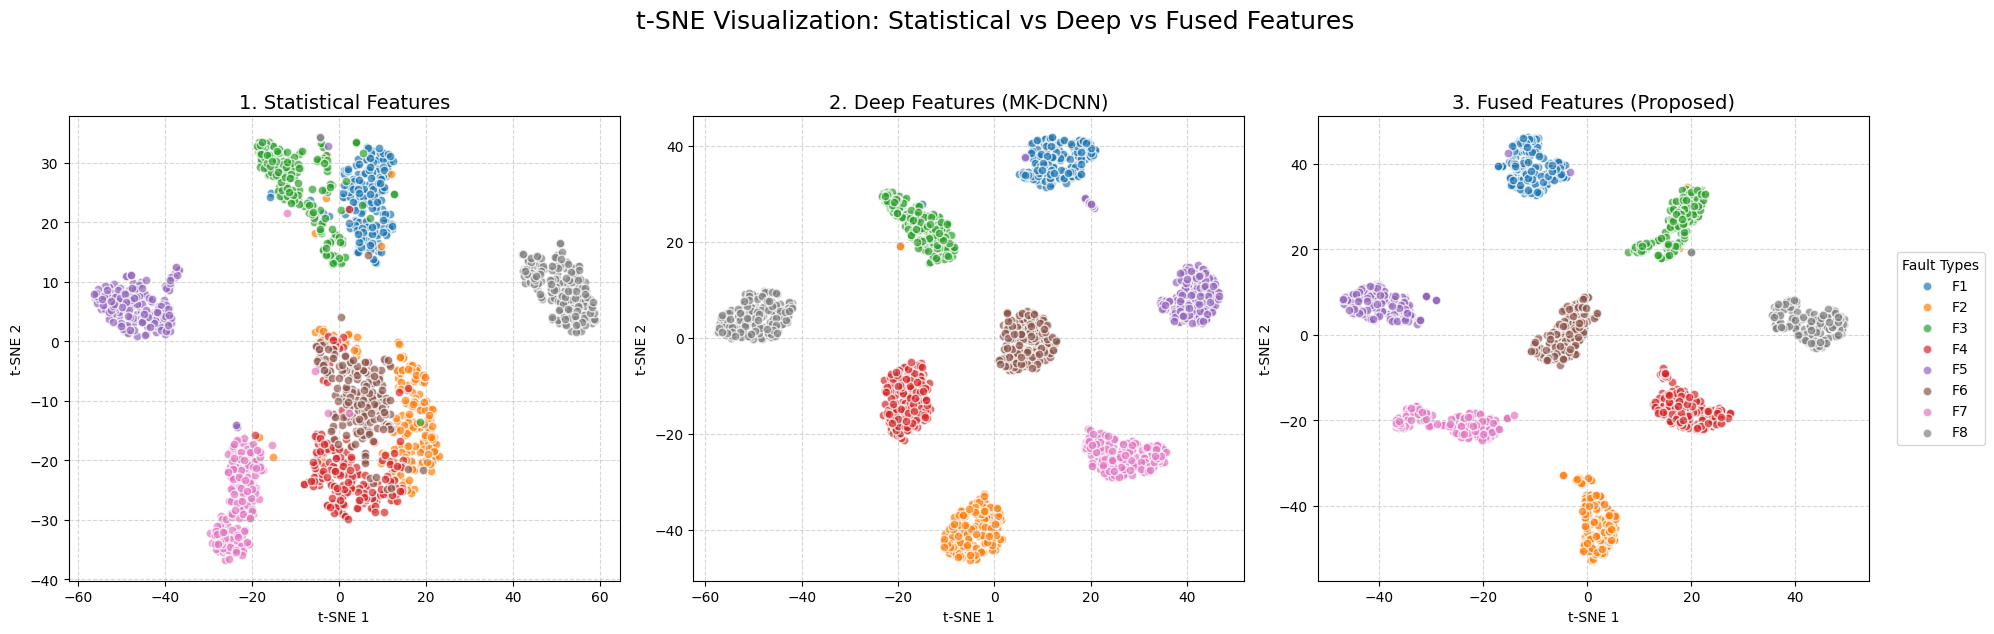

In [4]:
# =========================================================
# Cell 3: MK-DCNN 訓練、特徵融合 (Fusion) 與 t-SNE 視覺化
# =========================================================
def custom_loss(y_true, y_pred):
    loss = K.categorical_crossentropy(y_true, y_pred)
    if K.int_shape(y_pred)[-1] > 1:
        physics_term = tf.reduce_mean(tf.square(y_pred[:, 1:] - y_pred[:, :-1]))
    else:
        physics_term = 0.0
    return loss + 0.01 * physics_term

inputs = layers.Input(shape=(X_raw_balanced.shape[1], 1))
flat1 = layers.Flatten()(layers.MaxPooling1D(20)(layers.Dropout(0.5)(layers.Conv1D(64, 200, activation='relu')(inputs))))
flat2 = layers.Flatten()(layers.MaxPooling1D(10)(layers.Dropout(0.5)(layers.Conv1D(64, 100, activation='relu')(inputs))))
flat3 = layers.Flatten()(layers.MaxPooling1D(5)(layers.Dropout(0.5)(layers.Conv1D(64, 50, activation='relu')(inputs))))

merged = layers.concatenate([flat1, flat2, flat3])
dense_layer = layers.Dense(100, activation='relu', name='deep_feature')(merged)
outputs = layers.Dense(len(encoder.classes_), activation='softmax')(dense_layer)

cnn_model = models.Model(inputs=inputs, outputs=outputs)
cnn_model.compile(optimizer='adam', loss=custom_loss, metrics=['accuracy'])

# 1. 訓練 CNN 並提取深度特徵
print("1. 訓練 MK-DCNN 並提取深度特徵...")
cnn_model.fit(X_raw_balanced, y_categorical, batch_size=100, epochs=20, verbose=0) # verbose=0隱藏過程保持版面乾淨
dummy_cnn = models.Model(inputs=cnn_model.input, outputs=cnn_model.get_layer('deep_feature').output)
X_deep = dummy_cnn.predict(X_raw_balanced, verbose=0)

# 2. t-SNE 降維與特徵融合
print("2. 執行 t-SNE 降維與特徵融合...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_stat_tsne = tsne.fit_transform(StandardScaler().fit_transform(X_stat_balanced))
X_deep_tsne = tsne.fit_transform(X_deep)

# 完美水平融合: 2維統計 + 2維深度 = 4維融合特徵
X_fused_4d = np.concatenate((X_stat_tsne, X_deep_tsne), axis=1)
print(f"✅ 雙路徑特徵融合完成！CatBoost 最終輸入維度: {X_fused_4d.shape}")

# 3. 繪製 1x3 t-SNE 視覺化對比圖 (學術展示用)
print("3. 繪製特徵分佈 t-SNE 對比圖...")
X_fused_2d_plot = tsne.fit_transform(X_fused_4d) # 將 4D 融合特徵再降回 2D 方便畫圖

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("t-SNE Visualization: Statistical vs Deep vs Fused Features", fontsize=18, y=1.05)
feature_sets = [(X_stat_tsne, "1. Statistical Features"), (X_deep_tsne, "2. Deep Features (MK-DCNN)"), (X_fused_2d_plot, "3. Fused Features (Proposed)")]
palette = sns.color_palette("tab10", len(encoder.classes_))

for i, (feat_2d, title) in enumerate(feature_sets):
    ax = axes[i]
    for j, fault_class in enumerate(encoder.classes_):
        idx = np.where(y_label == fault_class)
        ax.scatter(feat_2d[idx, 0], feat_2d[idx, 1], label=fault_class, color=palette[j], alpha=0.7, edgecolors='w', s=40)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(True, linestyle='--', alpha=0.5)

axes[2].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Fault Types", borderaxespad=0.)
plt.tight_layout()
plt.show()

In [5]:
# =========================================================
# Cell 4: 原版 HS-PSO (具備動態繁衍與淘汰機制 + 計算成本追蹤)
# =========================================================
from catboost import CatBoostClassifier
import numpy as np
from sklearn.metrics import accuracy_score

class Original_HSPSO_Tracked:
    def __init__(self, X_tr, y_tr, X_va, y_va, search_space, n_part=10, max_iter=15, seed=42):
        self.X_tr, self.y_tr, self.X_va, self.y_va = X_tr, y_tr, X_va, y_va
        self.search_space = search_space
        self.keys = list(search_space.keys())
        self.dim, self.n_part, self.max_iter = len(self.keys), n_part, max_iter
        self.rng = np.random.default_rng(seed)

        # 基礎參數設定
        self.switch_threshold, self.w_min, self.w_max = 5, 0.5, 0.9
        self.c1, self.c2, self.mutation_prob, self.restart_prob = 0.8, 0.6, 0.15, 0.08
        self.target_acc, self.H, self.b = 0.999, 1.0, 0.9

        # [新增] 成本追蹤器 (記錄 CatBoost 被訓練了幾次)
        self.eval_count = 0

    def project_to_space(self, key, value):
        choices = np.array(self.search_space[key], dtype=float)
        v = self.search_space[key][int(np.argmin(np.abs(choices - float(value))))]
        return int(v) if isinstance(self.search_space[key][0], int) else float(v)

    def clip_cast(self, p):
        return {"iterations": int(self.project_to_space("iterations", p["iterations"])),
                "depth": int(self.project_to_space("depth", p["depth"])),
                "learning_rate": self.project_to_space("learning_rate", p["learning_rate"]),
                "l2_leaf_reg": self.project_to_space("l2_leaf_reg", p["l2_leaf_reg"]),
                "bagging_temperature": self.project_to_space("bagging_temperature", p["bagging_temperature"]),
                "random_strength": self.project_to_space("random_strength", p["random_strength"])}

    def obj_fast(self, p):
        self.eval_count += 1  # 每次訓練模型，計算成本 +1
        model = CatBoostClassifier(**self.clip_cast(p), loss_function="MultiClass", eval_metric="Accuracy",
                                   od_type="Iter", od_wait=20, verbose=False, random_seed=42, thread_count=-1)
        model.fit(self.X_tr, self.y_tr, eval_set=(self.X_va, self.y_va), use_best_model=True)
        return float(accuracy_score(self.y_va, model.predict(self.X_va).reshape(-1)))

    def pt_to_vec(self, p): return np.array([float(p[k]) for k in self.keys], dtype=float)
    def vec_to_pt(self, v): return {k: float(v[i]) for i, k in enumerate(self.keys)}

    def optimize(self):
        print(f"🚀 啟動 [原版] HS-PSO (包含動態淘汰與繁衍機制)...")
        print(f"   初始粒子數: {self.n_part}, 最大迭代: {self.max_iter}")

        swarm = [{k: self.rng.choice(self.search_space[k]) for k in self.keys} for _ in range(self.n_part)]
        vel = [np.zeros(self.dim, dtype=float) for _ in range(self.n_part)]
        pbest = [dict(s) for s in swarm]

        print("   [初始化] 正在評估初始粒子群...")
        pbest_score = [self.obj_fast(s) for s in swarm]
        gbest = dict(pbest[int(np.argmax(pbest_score))])
        gbest_score = float(np.max(pbest_score))
        topology = "gbest"

        for it in range(1, self.max_iter + 1):
            # [修改] 註解掉提早結束，強迫跑完以計算真實最大成本
            # if gbest_score >= self.target_acc: break

            w = self.w_max - ((self.w_max - self.w_min) * it) / (1.0 + np.exp(-10.0 * self.b * ((2.0 * it) / (self.H * self.max_iter) - 1.0)))
            if it % self.switch_threshold == 0: topology = "lbest" if topology == "gbest" else "gbest"

            scores = []
            for i in range(len(swarm)):
                s = self.obj_fast(swarm[i])
                scores.append(s)
                if s > pbest_score[i]:
                    pbest[i], pbest_score[i] = dict(swarm[i]), float(s)

            best_i = int(np.argmax(pbest_score))
            if pbest_score[best_i] > gbest_score:
                gbest, gbest_score = dict(pbest[best_i]), float(pbest_score[best_i])

            # --------------------------------------------------
            # [原版專屬] 動態繁衍與淘汰 (Dynamic Reproduction & Elimination)
            # --------------------------------------------------
            for idx in np.argsort(scores)[-max(1, len(swarm)//5):]:
                swarm.append(dict(swarm[idx]))
                vel.append(vel[idx].copy())
                scores.append(scores[idx])
                pbest.append(dict(pbest[idx]))
                pbest_score.append(float(pbest_score[idx]))

            if len(swarm) > 2 * self.n_part:
                for idx in sorted(np.argsort(scores)[:len(swarm)//4], reverse=True):
                    del swarm[idx], vel[idx], scores[idx], pbest[idx], pbest_score[idx]

            # 速度與位置更新 (依據浮動的 len(swarm))
            for i in range(len(swarm)):
                if topology == "gbest": g_vec = self.pt_to_vec(gbest)
                else: g_vec = self.pt_to_vec(pbest[self.rng.choice(len(swarm), min(5, len(swarm)), replace=False)[np.argmax([pbest_score[j] for j in self.rng.choice(len(swarm), min(5, len(swarm)), replace=False)])]])

                vel[i] = w * vel[i] + self.c1 * self.rng.random(self.dim) * (self.pt_to_vec(pbest[i]) - self.pt_to_vec(swarm[i])) + self.c2 * self.rng.random(self.dim) * (g_vec - self.pt_to_vec(swarm[i]))
                swarm[i] = self.clip_cast(self.vec_to_pt(self.pt_to_vec(swarm[i]) + vel[i]))

                # 原版固定的柯西變異 (gamma=0.25)
                if self.rng.random() < self.mutation_prob:
                    mut = dict(swarm[i])
                    for k in self.keys: mut[k] = self.project_to_space(k, float(mut[k]) * (1.0 + 0.25 * np.tan(np.pi * (self.rng.random() - 0.5))))
                    swarm[i] = self.clip_cast(mut)

                if self.rng.random() < self.restart_prob:
                    swarm[i] = {k: self.rng.choice(self.search_space[k]) for k in self.keys}

            print(f"迭代 {it}/{self.max_iter} - 最佳準確率: {gbest_score:.5f} (目前粒子人數: {len(swarm)})")

        # 回傳: 最佳參數, 最佳分數, 總評估次數
        return self.clip_cast(gbest), gbest_score, self.eval_count

🚀 啟動 [原版] HS-PSO (包含動態淘汰與繁衍機制)...
   初始粒子數: 10, 最大迭代: 15
   [初始化] 正在評估初始粒子群...
迭代 1/15 - 最佳準確率: 0.99203 (目前粒子人數: 12)
迭代 2/15 - 最佳準確率: 0.99203 (目前粒子人數: 14)
迭代 3/15 - 最佳準確率: 0.99203 (目前粒子人數: 16)
迭代 4/15 - 最佳準確率: 0.99203 (目前粒子人數: 19)
迭代 5/15 - 最佳準確率: 0.99203 (目前粒子人數: 17)
迭代 6/15 - 最佳準確率: 0.99203 (目前粒子人數: 20)
迭代 7/15 - 最佳準確率: 0.99203 (目前粒子人數: 18)
迭代 8/15 - 最佳準確率: 0.99203 (目前粒子人數: 16)
迭代 9/15 - 最佳準確率: 0.99203 (目前粒子人數: 19)
迭代 10/15 - 最佳準確率: 0.99203 (目前粒子人數: 17)
迭代 11/15 - 最佳準確率: 0.99203 (目前粒子人數: 20)
迭代 12/15 - 最佳準確率: 0.99203 (目前粒子人數: 18)
迭代 13/15 - 最佳準確率: 0.99203 (目前粒子人數: 16)
迭代 14/15 - 最佳準確率: 0.99203 (目前粒子人數: 19)
迭代 15/15 - 最佳準確率: 0.99203 (目前粒子人數: 17)
 🔬 [對照組] 原版 HS-PSO 計算成本報告
🔸 最佳超參數組合 : {'iterations': 50, 'depth': 7, 'learning_rate': 0.08, 'l2_leaf_reg': 3.0, 'bagging_temperature': 1.0, 'random_strength': 1.5}
🔸 尋優驗證準確率 : 0.9920
⏱️ 總耗時 (Time)   : 72.22 秒 (1.20 分鐘)
⚙️ 總成本 (Evals)  : 261 次 CatBoost 模型訓練


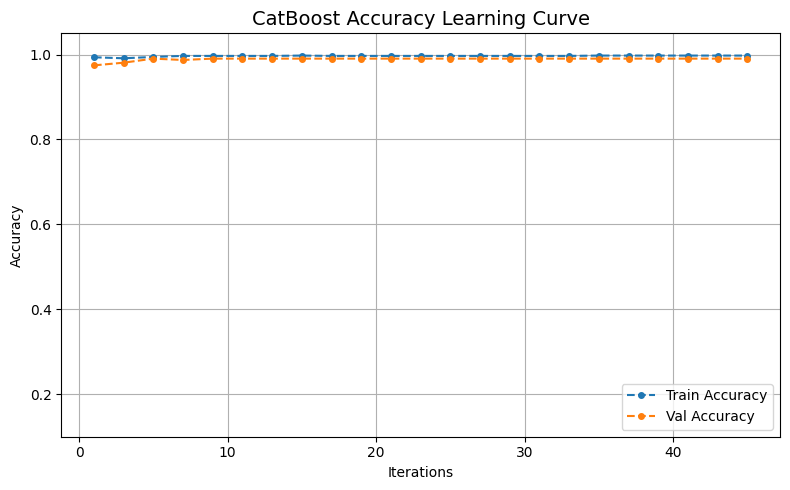


Classification Report - Test Set:
              precision    recall  f1-score   support

          F1       0.98      0.98      0.98        46
          F2       1.00      0.97      0.99        36
          F3       0.94      1.00      0.97        32
          F4       1.00      1.00      1.00        46
          F5       1.00      0.97      0.99        35
          F6       1.00      1.00      1.00        33
          F7       1.00      1.00      1.00        40
          F8       1.00      1.00      1.00        46

    accuracy                           0.99       314
   macro avg       0.99      0.99      0.99       314
weighted avg       0.99      0.99      0.99       314



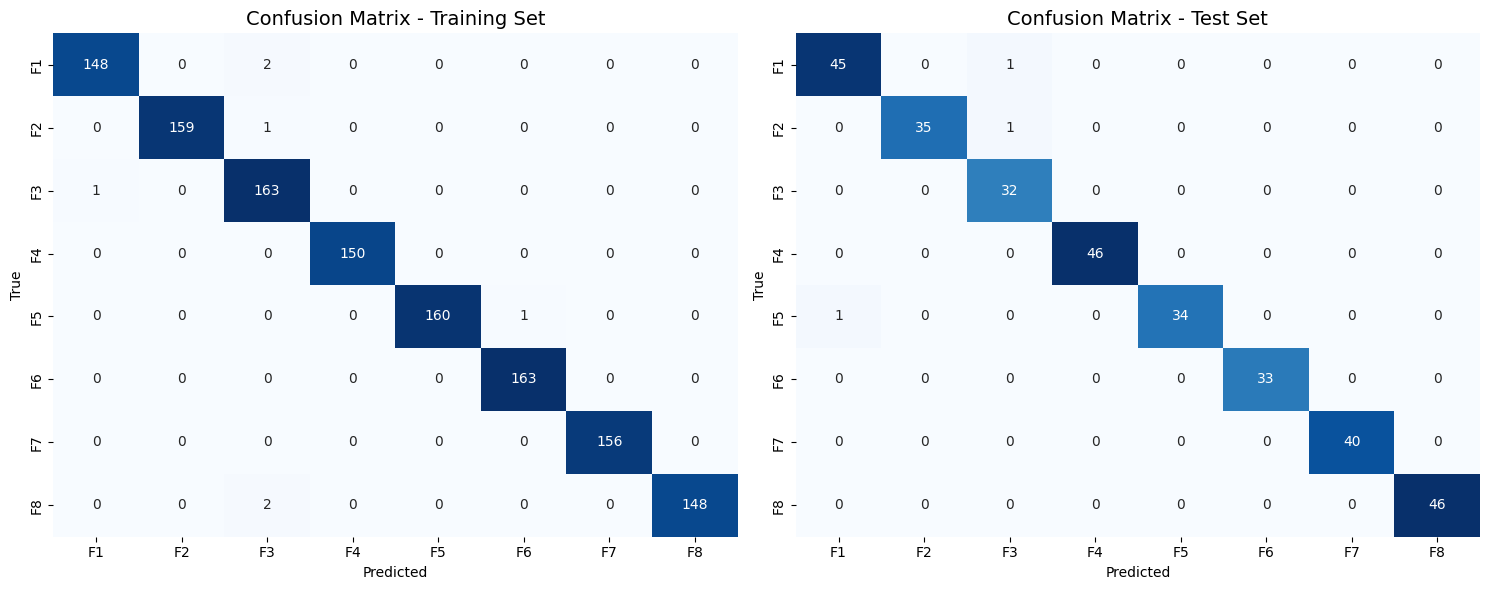

In [6]:
# =========================================================
# Cell 5: 部署原版 HS-PSO、結算成本與視覺化圖表
# =========================================================
from catboost import Pool
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. 拆分資料集 (如果前面已經跑過可視情況略過，這裡保證變數存在)
X_train, X_test, y_train, y_test = train_test_split(X_fused_4d, y_encoded, test_size=0.2, random_state=42)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(sss.split(X_train, y_train))
X_tr, y_tr, X_va, y_va = X_train[tr_idx], y_train[tr_idx], X_train[va_idx], y_train[va_idx]

search_space = {
    "iterations": list(range(50, 201, 25)), "depth": list(range(2, 9)),
    "learning_rate": [0.03, 0.05, 0.08, 0.1], "l2_leaf_reg": [1.0, 3.0, 5.0],
    "bagging_temperature": [0.5, 1.0, 1.5], "random_strength": [0.5, 1.0, 1.5]
}

# ---------------------------------------------------------
# 2. 執行原版 HS-PSO 並追蹤時間與成本
# ---------------------------------------------------------
start_time = time.time()
# 這裡呼叫的是 Cell 4 的 Original_HSPSO_Tracked
optimizer = Original_HSPSO_Tracked(X_tr, y_tr, X_va, y_va, search_space, n_part=10, max_iter=15)
best_params, best_acc, total_evals = optimizer.optimize()
end_time = time.time()

time_taken_sec = end_time - start_time

# ---------------------------------------------------------
# 📊 【原版基準】計算成本與時間比較報告
# ---------------------------------------------------------
print("="*50)
print(" 🔬 [對照組] 原版 HS-PSO 計算成本報告")
print("="*50)
print(f"🔸 最佳超參數組合 : {best_params}")
print(f"🔸 尋優驗證準確率 : {best_acc:.4f}")
print(f"⏱️ 總耗時 (Time)   : {time_taken_sec:.2f} 秒 ({time_taken_sec/60:.2f} 分鐘)")
print(f"⚙️ 總成本 (Evals)  : {total_evals} 次 CatBoost 模型訓練")
print("="*50)

# ---------------------------------------------------------
# 3. 部署最終 CatBoost 模型並畫圖
# ---------------------------------------------------------
final_model = CatBoostClassifier(**best_params, loss_function="MultiClass", eval_metric="Accuracy",
                                 od_type="Iter", od_wait=40, verbose=0, random_seed=42, thread_count=-1)
final_model.fit(Pool(X_train, y_train), eval_set=Pool(X_test, y_test), use_best_model=True)

# 學習曲線繪圖
curve = final_model.get_evals_result()
train_acc, val_acc = curve.get("learn", {}).get("Accuracy", []), curve.get("validation", {}).get("Accuracy", [])
if train_acc and val_acc:
    step = max(1, len(train_acc) // 20)
    x_axis = np.arange(1, len(train_acc) + 1, step)
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, np.array(train_acc)[::step], linestyle="--", marker="o", markersize=4, label="Train Accuracy")
    plt.plot(x_axis, np.array(val_acc)[::step], linestyle="--", marker="o", markersize=4, label="Val Accuracy")
    plt.title("CatBoost Accuracy Learning Curve", fontsize=14)
    plt.xlabel("Iterations"); plt.ylabel("Accuracy")
    plt.grid(True); plt.ylim(0.1, 1.05); plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# 混淆矩陣繪圖
y_pred_train, y_pred_test = final_model.predict(X_train).reshape(-1), final_model.predict(X_test).reshape(-1)
print("\nClassification Report - Test Set:")
print(classification_report(y_test, y_pred_test, target_names=encoder.classes_))

plt.figure(figsize=(15, 6))
for i, (yt, yp, title) in enumerate([(y_train, y_pred_train, "Training Set"), (y_test, y_pred_test, "Test Set")]):
    plt.subplot(1, 2, i+1)
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"Confusion Matrix - {title}", fontsize=14)
    plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()